In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
data = pd.read_csv('STD Cases.csv')

In [3]:
# Display the first few rows of the dataset
data.head()

,Disease,Disease Code,State,Year,Gender,Age,Age Code,STD Cases,Population,Rate per 100K
0,Chlamydia,274.0,Alabama,1996.0,Male,0-14 years,0-14,25.0,468394.0,5.34
1,Chlamydia,274.0,Alabama,1996.0,Male,15-19 years,15-19,164.0,165920.0,98.84
2,Chlamydia,274.0,Alabama,1996.0,Male,20-24 years,20-24,193.0,152848.0,126.27
3,Chlamydia,274.0,Alabama,1996.0,Male,25-29 years,25-29,88.0,152778.0,57.60
4,Chlamydia,274.0,Alabama,1996.0,Male,30-34 years,30-34,55.0,155850.0,35.29


In [4]:
# Check for missing values
print(data.isnull().sum())

Disease           150
Disease Code      150
State             150
Year              150
Gender            150
Age               150
Age Code          150
STD Cases         150
Population       7197
Rate per 100K    7197
dtype: int64


In [5]:
data.duplicated().sum()

149

In [6]:
# Drop rows with missing target values ('STD Cases' or 'Rate per 100K')
data = data.dropna(subset=['STD Cases', 'Rate per 100K'])

In [7]:
# Fill missing values in 'Population' with the median value
data['Population'] = data['Population'].fillna(data['Population'].median())

In [8]:
# Convert 'Year' to integer
data['Year'] = data['Year'].astype(int)

# Convert 'Age' and 'Age Code' columns to string if they are not already
data['Age'] = data['Age'].astype(str)
data['Age Code'] = data['Age Code'].astype(str)

# Encode categorical variables using one-hot encoding
data = pd.get_dummies(data, columns=['Disease', 'State', 'Gender', 'Age', 'Age Code'], drop_first=True)

# Display cleaned data
data.head()

,Disease Code,Year,STD Cases,Population,Rate per 100K,Disease_Gonorrhea,Disease_Primary and Secondary Syphilis,State_Alaska,State_Arizona,State_Arkansas,...,Age_25-29 years,Age_30-34 years,Age_35-39 years,Age_40+ years,Age Code_15-19,Age Code_20-24,Age Code_25-29,Age Code_30-34,Age Code_35-39,Age Code_40+
0,274.0,1996,25.0,468394.0,5.34,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,274.0,1996,164.0,165920.0,98.84,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
2,274.0,1996,193.0,152848.0,126.27,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,274.0,1996,88.0,152778.0,57.60,False,False,False,False,False,...,True,False,False,False,False,False,True,False,False,False
4,274.0,1996,55.0,155850.0,35.29,False,False,False,False,False,...,False,True,False,False,False,False,False,True,False,False


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35483 entries, 0 to 42629
Data columns (total 70 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Disease Code                            35483 non-null  float64
 1   Year                                    35483 non-null  int32  
 2   STD Cases                               35483 non-null  float64
 3   Population                              35483 non-null  float64
 4   Rate per 100K                           35483 non-null  float64
 5   Disease_Gonorrhea                       35483 non-null  bool   
 6   Disease_Primary and Secondary Syphilis  35483 non-null  bool   
 7   State_Alaska                            35483 non-null  bool   
 8   State_Arizona                           35483 non-null  bool   
 9   State_Arkansas                          35483 non-null  bool   
 10  State_California                        35483 non-null  bool   

In [9]:
from sklearn.model_selection import train_test_split

# Define features and target variable
features = data.drop(['STD Cases', 'Rate per 100K'], axis=1)
target = data['STD Cases']  # You can also use 'Rate per 100K' as the target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (28386, 68)
Testing set: (7097, 68)


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Support Vector Regressor': SVR(),
    'K-Nearest Neighbors': KNeighborsRegressor()
}

In [11]:
# Dictionary to store model performance
model_performance = {}

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    # Make predictions
    y_pred = model.predict(X_test)
    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    # Store the results
    model_performance[model_name] = {'MSE': mse, 'R2': r2}
    print(f'{model_name} - Mean Squared Error: {mse:.2f}, R^2 Score: {r2:.2f}')

Linear Regression - Mean Squared Error: 2531424.25, R^2 Score: 0.35
Random Forest - Mean Squared Error: 40613.95, R^2 Score: 0.99
Gradient Boosting - Mean Squared Error: 974841.82, R^2 Score: 0.75
Support Vector Regressor - Mean Squared Error: 4197015.53, R^2 Score: -0.08
K-Nearest Neighbors - Mean Squared Error: 4414706.48, R^2 Score: -0.14


In [12]:
# Convert the model performance dictionary to a DataFrame for easier comparison
performance_df = pd.DataFrame(model_performance).T

# Display the performance DataFrame
print(performance_df)

                                   MSE        R2
Linear Regression         2.531424e+06  0.346829
Random Forest             4.061395e+04  0.989521
Gradient Boosting         9.748418e+05  0.748467
Support Vector Regressor  4.197016e+06 -0.082935
K-Nearest Neighbors       4.414706e+06 -0.139104


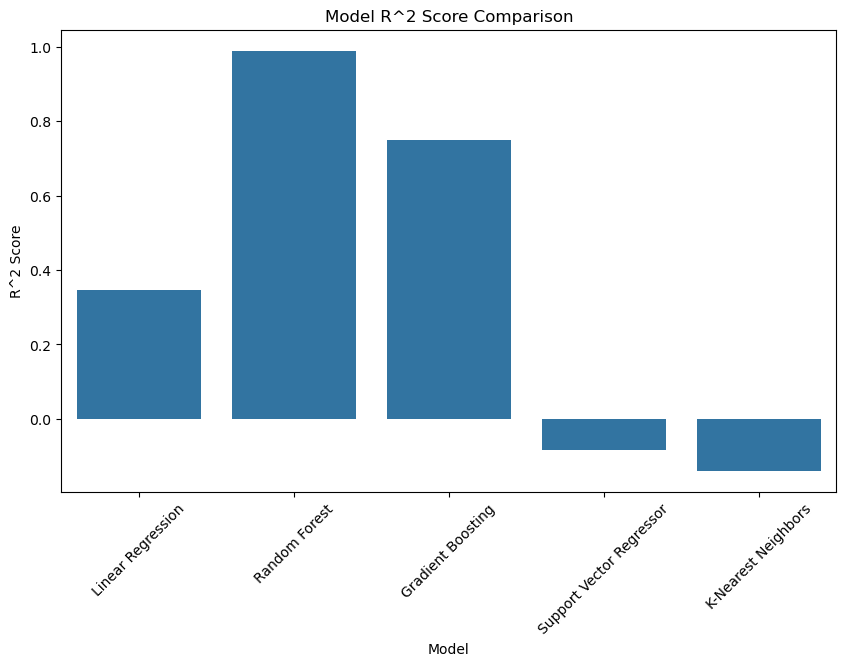

In [13]:
# Plot R^2 scores for comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_df.index, y='R2', data=performance_df)
plt.title('Model R^2 Score Comparison')
plt.xlabel('Model')
plt.ylabel('R^2 Score')
plt.xticks(rotation=45)
plt.show()

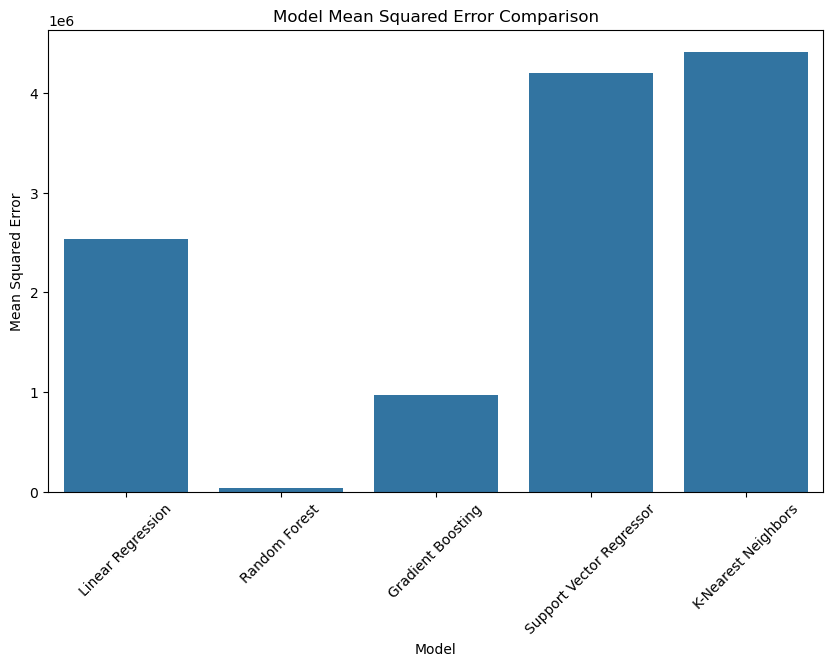

In [14]:
# Plot Mean Squared Errors for comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=performance_df.index, y='MSE', data=performance_df)
plt.title('Model Mean Squared Error Comparison')
plt.xlabel('Model')
plt.ylabel('Mean Squared Error')
plt.xticks(rotation=45)
plt.show()

In [16]:
# Access the Random Forest model from the dictionary
random_forest_model = models['Random Forest']

In [17]:
import pickle

# Save the Random Forest model to a file
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(random_forest_model, f)

['Disease Code', 'Year', 'Population', 'Disease_Gonorrhea', 'Disease_Primary and Secondary Syphilis', 'State_Alaska', 'State_Arizona', 'State_Arkansas', 'State_California', 'State_Colorado', 'State_Connecticut', 'State_Delaware', 'State_District of Columbia', 'State_Florida', 'State_Georgia', 'State_Hawaii', 'State_Idaho', 'State_Illinois', 'State_Indiana', 'State_Iowa', 'State_Kansas', 'State_Kentucky', 'State_Louisiana', 'State_Maine', 'State_Maryland', 'State_Massachusetts', 'State_Michigan', 'State_Minnesota', 'State_Mississippi', 'State_Missouri', 'State_Montana', 'State_Nebraska', 'State_Nevada', 'State_New Hampshire', 'State_New Jersey', 'State_New Mexico', 'State_New York', 'State_North Carolina', 'State_North Dakota', 'State_Ohio', 'State_Oklahoma', 'State_Oregon', 'State_Pennsylvania', 'State_Rhode Island', 'State_South Carolina', 'State_South Dakota', 'State_Tennessee', 'State_Texas', 'State_Utah', 'State_Vermont', 'State_Virginia', 'State_Washington', 'State_West Virginia',